In [35]:
import numpy as np
import matplotlib.pyplot as plt

print("Setup complete!")


Setup complete!


In [36]:
# ============ Simulation Parameters ============
dt = 0.001          # 1 ms time step
T = 1.0             # total simulation time (1 second)
time = np.arange(0, T, dt)

# ============ Neuron Parameters ============
V_rest = -70.0      # resting potential (mV)
V_thresh = -55.0    # spike threshold (mV)
V_reset = -75.0     # reset potential after spike (mV)
tau = 0.020         # membrane time constant (20 ms)
C = 1.0             # membrane capacitance

print(f"Simulation length: {T} s")
print(f"Number of time steps: {len(time)}")


Simulation length: 1.0 s
Number of time steps: 1000


In [37]:
# ============ Input Current ============
I_input = np.zeros(len(time))

# Inject current from 0.2s to 0.8s
start_index = int(0.2 / dt)
end_index = int(0.8 / dt)

I_input[start_index:end_index] = 800.0

print("Input current configured.")


Input current configured.


In [38]:
# ============ Storage Arrays ============
V = np.zeros(len(time))
V[0] = V_rest
spikes = []

# ============ Simulation Loop ============
for t in range(len(time) - 1):

    # LIF equation
    dV = dt * (-(V[t] - V_rest) / tau + I_input[t] / C)

    # Update voltage
    V[t+1] = V[t] + dV

    # Spike detection
    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f"Neuron fired {len(spikes)} spikes")


Neuron fired 10 spikes


In [39]:
print("Max voltage reached:", np.max(V))


Max voltage reached: -55.00275461230366


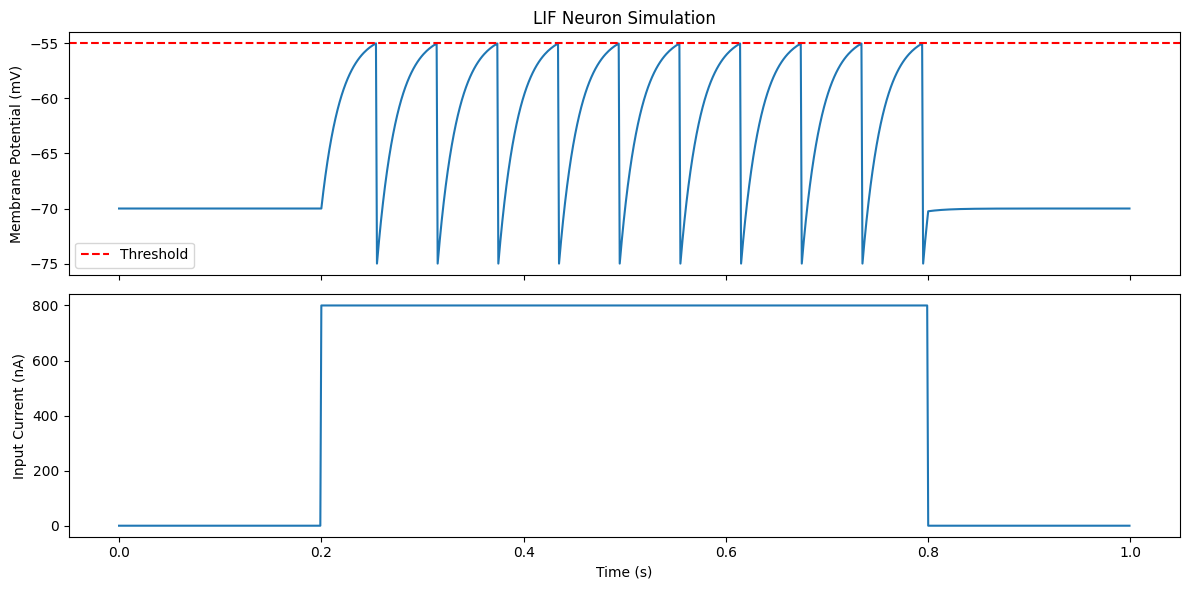

In [40]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(time, V)
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')
ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

ax2.plot(time, I_input)
ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()


## Knowledge Check – Part A

1. Why is V_reset (-75 mV) lower than V_rest (-70 mV)? What biological phenomenon does this represent?

V_reset is lower than V_rest to represent the refractory or hyperpolarization period after a neuron fires. In biological neurons, after an action potential, ion channels cause the membrane potential to briefly drop below resting potential before returning to rest. This prevents immediate re-firing and creates a realistic spike-reset cycle.

2. The time constant tau is 20 ms. In plain English, what does this control?

The time constant tau controls how quickly the membrane potential changes. A small tau means the neuron leaks voltage quickly and responds faster to input but cannot hold charge long. A larger tau means the neuron integrates input more slowly and holds charge longer before leaking back to rest.

In [41]:
def rate_encode(values, num_steps=100):
    """
    Convert values (0–1) into spike trains using rate coding.
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        random_values = np.random.rand(num_neurons)
        spikes[t] = (random_values < values).astype(float)

    return spikes


In [42]:
# Test with increasing values
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f"Value {v:.1f} -> {count:.0f} spikes in 200 steps")


Value 0.1 -> 22 spikes in 200 steps
Value 0.3 -> 59 spikes in 200 steps
Value 0.5 -> 99 spikes in 200 steps
Value 0.7 -> 134 spikes in 200 steps
Value 0.9 -> 179 spikes in 200 steps


## Knowledge Check – Rate vs Temporal Coding

1. In rate coding, the information about the exact timing of individual spikes is lost. What is preserved is the overall firing rate, meaning how many spikes occur over time. The signal strength is represented by spike frequency rather than precise timing.

2. In temporal coding, a downstream neuron can make decisions faster because important signals arrive earlier in time. Instead of waiting to count many spikes, the neuron can respond based on when the first spike occurs.

3. A real-world example where timing matters more than frequency is sound localization. The brain compares very small timing differences between when a sound reaches each ear to determine direction.


In [43]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0–1) into spike trains using time-to-first-spike coding.
    Higher values spike earlier.
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
            spike_time = int((1 - values[i]) * (num_steps - 1))
            spikes[spike_time, i] = 1

    return spikes


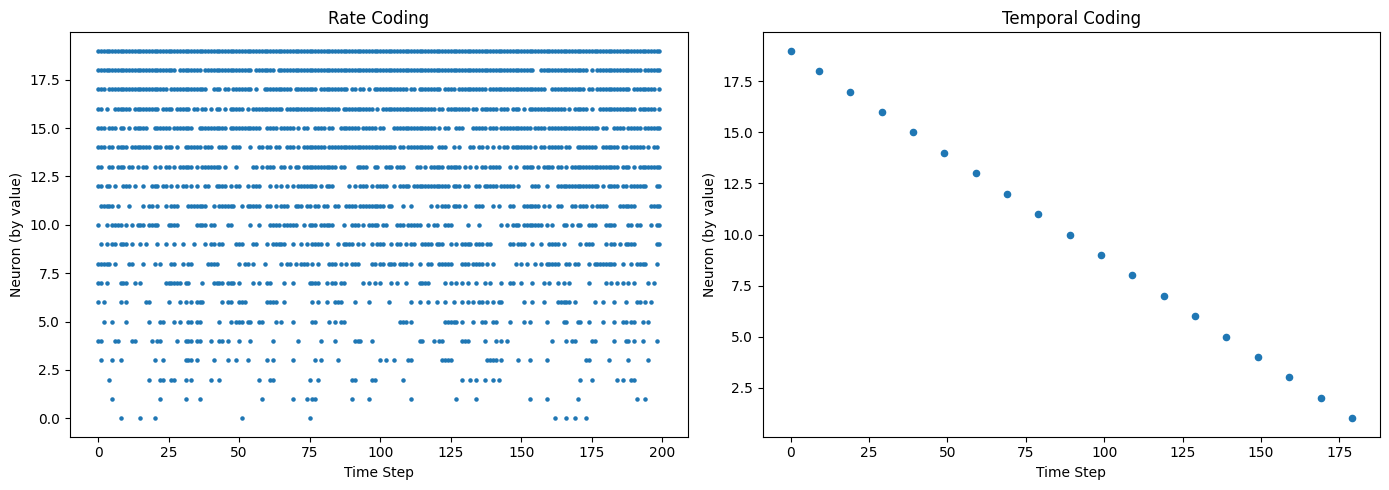

In [44]:
# Create test signal (20 values from 0.05 to 1.0)
signal = np.linspace(0.05, 1.0, 20)

# Encode using both methods
rate_spikes = rate_encode(signal, num_steps=200)
temp_spikes = temporal_encode(signal, num_steps=200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ----- Rate Coding Raster -----
times, neurons = np.where(rate_spikes == 1)
ax1.scatter(times, neurons, s=5)
ax1.set_title("Rate Coding")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Neuron (by value)")

# ----- Temporal Coding Raster -----
times, neurons = np.where(temp_spikes == 1)
ax2.scatter(times, neurons, s=20)
ax2.set_title("Temporal Coding")
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Neuron (by value)")

plt.tight_layout()
plt.show()


## Reflection – Comparing Rate and Temporal Coding

Rate coding spreads spikes across time, and the strength of the signal is represented by how many spikes occur. It is useful when a system needs reliable measurement over time, since averaging spike frequency reduces noise.

Temporal coding encodes information in when a spike occurs. Higher values spike earlier, creating a fast decision signal. This would be better for systems that need to react quickly rather than wait to count many spikes.

The brain likely uses both strategies because some circuits require rapid responses (like reflexes or sound localization), while others need precise measurement over time (like sensory integration or perception).


In [49]:
# ============ Mini Spiking Network ============

num_neurons = 3

# Weight matrix (simple feedforward chain)
W = np.array([
    [0.0, 4000.0, 0.0],   # Neuron 1 excites Neuron 2
    [0.0, 0.0, 4000.0],   # Neuron 2 excites Neuron 3
    [0.0, 0.0, 0.0]    # Neuron 3 outputs nowhere
])

print("Weight matrix:")
print(W)


Weight matrix:
[[   0. 4000.    0.]
 [   0.    0. 4000.]
 [   0.    0.    0.]]


In [50]:
# ===== Mini Spiking Network (Rebuilt Clean) =====

# Storage
V_net = np.zeros((len(time), num_neurons))
V_net[0, :] = V_rest

spikes_net = np.zeros((len(time), num_neurons))

# External input only to neuron 0
I_net = np.zeros((len(time), num_neurons))
I_net[:, 0] = I_input

# ===== Simulation =====

syn_current = np.zeros(num_neurons)

for t in range(len(time) - 1):

    # Synaptic current decays slowly and accumulates
    syn_current = 0.98 * syn_current + np.dot(spikes_net[t], W)

    for n in range(num_neurons):

        dV = dt * (-(V_net[t, n] - V_rest) / tau +
                   (I_net[t, n] + syn_current[n]) / C)

        V_net[t+1, n] = V_net[t, n] + dV

        if V_net[t+1, n] >= V_thresh:
            spikes_net[t+1, n] = 1
            V_net[t+1, n] = V_reset


In [51]:
print("Total spikes per neuron:",
      spikes_net.sum(axis=0))


Total spikes per neuron: [ 10.  83. 605.]


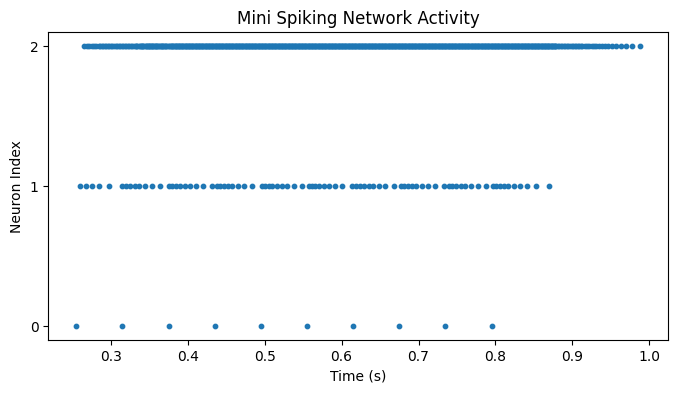

In [52]:
plt.figure(figsize=(8, 4))

times, neurons = np.where(spikes_net == 1)
plt.scatter(times * dt, neurons, s=10)

plt.title("Mini Spiking Network Activity")
plt.xlabel("Time (s)")
plt.ylabel("Neuron Index")
plt.yticks([0,1,2])

plt.show()
